# Bengali Multi-Label Cyberbullying Detection v7 (Lightweight, NO param cap)

**Track 1 — best-effort from-scratch model.** Predicts 4 toxic labels (`vulgar`, `threat`,
`troll`, `insult`); `neutral` is **derived** as `NOT(any toxic)`.

### Changes in v7
- **The ~10M parameter cap is removed.** The architecture is scaled up (projection 256→300,
  char-CNN 64→96 filters, TextCNN 224→256, BiGRU 368→512 hidden, FC 320→512) to use as much
  capacity as is useful. The exact parameter count is printed in Section 12.
- **Fixed the learning-rate collapse at unfreeze.** Previously, unfreezing created a new optimizer
  whose body LR dropped ~3x and then decayed linearly, so the body barely trained afterwards. Now
  the body keeps its full LR on a single cosine decay over the remaining steps; only the embeddings
  use a small (0.1x) LR.
- **Stronger regularization** to keep the larger model from overfitting on ~12k comments:
  dropout 0.5, embedding spatial-dropout 0.45, word-dropout 0.30, weight-decay 1e-3.

Everything correct is kept: split-before-augment with hard zero-leakage assertions, all-class
train-only augmentation, vocab built on original (pre-aug) text, Focal loss without `pos_weight`,
derived neutral, per-class threshold tuning, multi-seed ensemble, `nn.DataParallel` for **T4 x2**.

> **Honest note.** This model is data/label-limited (the subjective, overlapping `troll`/`insult`
> labels cap it around ~0.71-0.75). Adding parameters mainly increases the reported size, not
> accuracy; the transformer notebook is where the real accuracy gain lives.


In [1]:
# Section 1: Setup & Imports
!pip install iterative-stratification -q

import os, re, math, random, time, json, copy, gzip, warnings
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

from sklearn.metrics import (
    f1_score, classification_report, hamming_loss,
    roc_auc_score, average_precision_score
)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

NUM_GPUS = torch.cuda.device_count()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}')
print(f'Device: {device} | GPUs available: {NUM_GPUS}')
for i in range(NUM_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {p.name} ({p.total_memory/1e9:.1f} GB)')


PyTorch 2.10.0+cu128
Device: cuda | GPUs available: 2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)


In [2]:
# Section 2: Configuration (NO param cap, scaled up + anti-overfitting)

class Config:
    DATA_PATH = '/kaggle/input/datasets/muhammedjunayed/bengalicyber/combined_multi_labeled_bengali_comments_balanced_13k_14k_plus_neutral_plus_threat300.csv'
    TEXT_COL = 'text'
    LABEL_COLS = ['vulgar', 'threat', 'troll', 'insult', 'neutral']
    TOXIC_COLS = ['vulgar', 'threat', 'troll', 'insult']
    NUM_OUT = 4
    NEUTRAL_COL = 'neutral'

    # --- Text Processing ---
    MIN_WORDS = 2
    VOCAB_SIZE = 40000
    MIN_FREQ = 2
    MAX_LEN = 80

    # --- Character CNN (scaled up) ---
    CHAR_VOCAB_SIZE = 300
    MAX_CHAR_PER_WORD = 16
    CHAR_EMBED_DIM = 48
    CHAR_CNN_FILTERS = 96
    CHAR_KERNELS = (2, 3, 4)

    # --- Embeddings ---
    USE_PRETRAINED = True
    FASTTEXT_DIM = 300
    FREEZE_EMBEDDING = True
    UNFREEZE_AT_EPOCH = 6
    UNFREEZE_LR_FACTOR = 0.1
    PROJECTION_DIM = 300

    # --- Split ---
    TEST_FRAC = 0.15
    VAL_FRAC = 0.15

    # --- Model Architecture (scaled; NO 10M cap) ---
    CNN_FILTERS = 256
    CNN_KERNELS = (2, 3, 4)
    GRU_HIDDEN = 512
    GRU_LAYERS = 2
    FC_HIDDEN = 512
    DROPOUT_EMB = 0.45
    DROPOUT = 0.5
    NUM_DROPOUT_SAMPLES = 5

    # --- Training ---
    BATCH_SIZE_PER_GPU = 64
    EPOCHS = 35
    LR = 8e-4
    WEIGHT_DECAY = 1e-3
    WARMUP_RATIO = 0.10
    GRAD_CLIP = 1.0
    LABEL_SMOOTHING = 0.05

    # --- Loss ---
    USE_FOCAL_LOSS = True
    FOCAL_GAMMA = 2.0
    USE_POS_WEIGHT = False

    # --- Regularization ---
    WORD_DROPOUT_P = 0.30

    # --- Early Stopping ---
    PATIENCE = 8
    DEFAULT_THRESHOLD = 0.5

    # --- All-class TRAIN-ONLY augmentation ---
    AUGMENT = True
    AUG_TARGET = {'vulgar': 4800, 'threat': 4800, 'troll': 4800, 'insult': 5200, 'neutral': 4500}
    AUG_MAX_TOTAL = 26000

    # --- Threshold tuning ---
    THRESH_MIN = 0.30
    THRESH_MAX = 0.70
    THRESH_STEP = 0.02

    ENSEMBLE_SEEDS = [42, 7, 2024]

cfg = Config()
EFFECTIVE_BATCH = cfg.BATCH_SIZE_PER_GPU * max(NUM_GPUS, 1)
print(f'Effective batch size: {EFFECTIVE_BATCH} ({cfg.BATCH_SIZE_PER_GPU} x {max(NUM_GPUS,1)} GPU)')
print(f'Model predicts {cfg.NUM_OUT} toxic labels; "neutral" is derived as NOT(any toxic).')
print(f'Phases: Frozen(1-{cfg.UNFREEZE_AT_EPOCH-1}) -> Unfrozen({cfg.UNFREEZE_AT_EPOCH}-{cfg.EPOCHS})')
print('Parameter cap: NONE (architecture scaled up; exact count printed in Section 12)')


Effective batch size: 128 (64 x 2 GPU)
Model predicts 4 toxic labels; "neutral" is derived as NOT(any toxic).
Phases: Frozen(1-5) -> Unfrozen(6-35)
Parameter cap: NONE (architecture scaled up; exact count printed in Section 12)


In [3]:
# Section 3: Load + Clean + Deduplicate (on CLEANED text) + Derive neutral

data_paths = [
    cfg.DATA_PATH,
    f'/kaggle/input/datasets/muhammedjunayed/bengalicyber/{cfg.DATA_PATH}',
    f'/kaggle/input/datasets/keepsmiling15/15518-cyberbullying-bengali-cmnt/{cfg.DATA_PATH}',
    f'/kaggle/input/bengali-cyberbullying-15k/{cfg.DATA_PATH}',
    f'./{cfg.DATA_PATH}',
]
df = None
for p in data_paths:
    if os.path.exists(p):
        df = pd.read_csv(p); print(f'Loaded dataset from: {p}'); break
if df is None:
    raise FileNotFoundError(f'Dataset not found. Tried: {data_paths}')
print(f'Raw dataset: {len(df)} rows, columns: {list(df.columns)}')

for col in cfg.LABEL_COLS:
    assert col in df.columns, f'Missing column: {col}'
    df[col] = df[col].astype(int)

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#(\w+)')
EMOJI_RE = re.compile(
    '[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
    '\U0001F680-\U0001F6FF\U0001F900-\U0001F9FF'
    '\U00002702-\U000027B0]+', flags=re.UNICODE)
PUNCT_RE = re.compile(r'[^\u0980-\u09FF\s]')

def clean_text(text):
    text = str(text).strip()
    text = URL_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text)
    text = HASHTAG_RE.sub(r'\1', text)
    text = EMOJI_RE.sub(' ', text)
    text = PUNCT_RE.sub(' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df[cfg.TEXT_COL].apply(clean_text)
df['_wc'] = df['clean_text'].str.split().str.len().fillna(0)
df = df[df['_wc'] >= cfg.MIN_WORDS].copy()

before = len(df)
df = df.groupby('clean_text', as_index=False)[cfg.LABEL_COLS].max()
print(f'Deduplicated on cleaned text: {before} -> {len(df)}')

tox = df[cfg.TOXIC_COLS].sum(axis=1) > 0
df[cfg.NEUTRAL_COL] = (~tox).astype(int)
df[cfg.TEXT_COL] = df['clean_text']
df = df.reset_index(drop=True)

print('\nPer-class distribution (full, post-clean):')
for col in cfg.LABEL_COLS:
    n = int(df[col].sum())
    print(f'  {col:>8s}: {n:>5d} ({100*n/len(df):.1f}%)')
print(f'  {"TOTAL":>8s}: {len(df)}')


Loaded dataset from: /kaggle/input/datasets/muhammedjunayed/bengalicyber/combined_multi_labeled_bengali_comments_balanced_13k_14k_plus_neutral_plus_threat300.csv
Raw dataset: 15517 rows, columns: ['text', 'vulgar', 'threat', 'troll', 'insult', 'neutral']
Deduplicated on cleaned text: 15460 -> 15293

Per-class distribution (full, post-clean):
    vulgar:  3803 (24.9%)
    threat:  2140 (14.0%)
     troll:  4339 (28.4%)
    insult:  4364 (28.5%)
   neutral:  5457 (35.7%)
     TOTAL: 15293


## Section 4: Stratified split **before** any augmentation (zero-leakage guarantee)

In [4]:
# Section 5: Stratified Train/Val/Test Split (BEFORE augmentation)

labels_array = df[cfg.LABEL_COLS].values
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=cfg.TEST_FRAC, random_state=SEED)
trainval_idx, test_idx = next(msss1.split(df, labels_array))

df_tv = df.iloc[trainval_idx].reset_index(drop=True)
val_ratio = cfg.VAL_FRAC / (1.0 - cfg.TEST_FRAC)
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=SEED)
tr_sub, val_sub = next(msss2.split(df_tv, df_tv[cfg.LABEL_COLS].values))

df_train = df_tv.iloc[tr_sub].reset_index(drop=True)
df_val   = df_tv.iloc[val_sub].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print('\nPer-class rates per split:')
for name, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f'  {name}: {{' + ', '.join(f"{c}: {d[c].mean():.3f}" for c in cfg.LABEL_COLS) + '}}')

VAL_TEST_TEXTS = set(df_val['clean_text']) | set(df_test['clean_text'])


Train: 10677 | Val: 2327 | Test: 2289

Per-class rates per split:
  Train: {vulgar: 0.249, threat: 0.140, troll: 0.284, insult: 0.286, neutral: 0.358}}
  Val: {vulgar: 0.245, threat: 0.138, troll: 0.280, insult: 0.281, neutral: 0.352}}
  Test: {vulgar: 0.249, threat: 0.140, troll: 0.284, insult: 0.286, neutral: 0.358}}


## Section 6: All-class augmentation (training split only)

Augment every category up to a per-class target (rarer classes pulled up more) via word swap,
deletion, and pseudo-synonym duplication. Expands ~12k → ~20k+. Any augmented string colliding
with val/test is dropped; a hard assertion proves zero overlap between splits.


In [5]:
# Section 7: All-class TRAIN-ONLY augmentation + leakage guard

def random_swap(words):
    if len(words) < 2: return words
    words = words.copy(); i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]; return words

def random_deletion(words, p=0.1):
    if len(words) <= 2: return words
    kept = [w for w in words if random.random() > p]
    return kept if len(kept) >= 2 else words[:2]

def char_noise(word):
    if len(word) <= 1: return word
    c = list(word); i = random.randint(0, len(c)-2)
    c[i], c[i+1] = c[i+1], c[i]; return ''.join(c)

def synonym_perturbation(words):
    if len(words) < 2: return words
    words = words.copy(); i = random.randint(0, len(words)-1)
    words.insert(i+1, char_noise(words[i])); return words

def augment_text(text):
    words = text.split()
    kind = random.choice(['swap', 'swap', 'delete', 'synonym'])
    if kind == 'swap': words = random_swap(words)
    elif kind == 'delete': words = random_deletion(words)
    else: words = synonym_perturbation(words)
    return ' '.join(words)

def augment_all_train_only(df_train, cfg, forbidden_texts):
    df_train = df_train.copy()
    df_train['is_aug'] = 0
    if not cfg.AUGMENT:
        return df_train
    categories = cfg.TOXIC_COLS + [cfg.NEUTRAL_COL]
    extra = []
    for col in categories:
        pool = df_train[df_train[col] == 1]
        if len(pool) == 0:
            continue
        need = int(cfg.AUG_TARGET.get(col, 0)) - len(pool)
        if need <= 0:
            continue
        added = 0; attempts = 0
        while added < need and attempts < need * 3:
            attempts += 1
            row = pool.sample(1).iloc[0].copy()
            txt = augment_text(str(row['clean_text']))
            if txt in forbidden_texts or len(txt.split()) < cfg.MIN_WORDS:
                continue
            row['clean_text'] = txt; row[cfg.TEXT_COL] = txt; row['is_aug'] = 1
            extra.append(row); added += 1
        print(f'  {col:>8s}: pool={len(pool):>5d} -> +{added} augmented (target {cfg.AUG_TARGET.get(col)})')
    aug = pd.DataFrame(extra)
    out = pd.concat([df_train, aug], ignore_index=True)
    if len(out) > cfg.AUG_MAX_TOTAL:
        orig = out[out['is_aug'] == 0]
        aug_only = out[out['is_aug'] == 1].sample(n=max(0, cfg.AUG_MAX_TOTAL - len(orig)), random_state=SEED)
        out = pd.concat([orig, aug_only], ignore_index=True)
        print(f'  capped train size at {cfg.AUG_MAX_TOTAL}')
    return out

print('All-class train-only augmentation:')
df_train = augment_all_train_only(df_train, cfg, VAL_TEST_TEXTS)

for d in (df_train, df_val, df_test):
    d['tokens'] = d['clean_text'].str.split()

tr_texts = set(df_train['clean_text'])
leak_val = tr_texts & set(df_val['clean_text'])
leak_test = tr_texts & set(df_test['clean_text'])
print(f'\nLeakage check -> train∩val={len(leak_val)}, train∩test={len(leak_test)}')
assert not leak_val and not leak_test, 'LEAKAGE DETECTED between splits!'
for name, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    tox = d[cfg.TOXIC_COLS].sum(axis=1) > 0
    bad = int(((tox & (d[cfg.NEUTRAL_COL] == 1)) | (~tox & (d[cfg.NEUTRAL_COL] == 0))).sum())
    assert bad == 0, f'neutral inconsistency in {name}: {bad}'
print('Leakage = 0 and neutral labels consistent in all splits.')

print(f'\nTrain size after augmentation: {len(df_train)}')
print('Train per-class distribution:')
for col in cfg.LABEL_COLS:
    n = int(df_train[col].sum())
    print(f'  {col:>8s}: {n:>5d} ({100*n/len(df_train):.1f}%)')


All-class train-only augmentation:
    vulgar: pool= 2662 -> +2138 augmented (target 4800)
    threat: pool= 1498 -> +3302 augmented (target 4800)
     troll: pool= 3037 -> +1763 augmented (target 4800)
    insult: pool= 3054 -> +2146 augmented (target 5200)
   neutral: pool= 3819 -> +681 augmented (target 4500)

Leakage check -> train∩val=0, train∩test=0
Leakage = 0 and neutral labels consistent in all splits.

Train size after augmentation: 20707
Train per-class distribution:
    vulgar:  7237 (34.9%)
    threat:  5569 (26.9%)
     troll:  5981 (28.9%)
    insult:  8025 (38.8%)
   neutral:  4500 (21.7%)


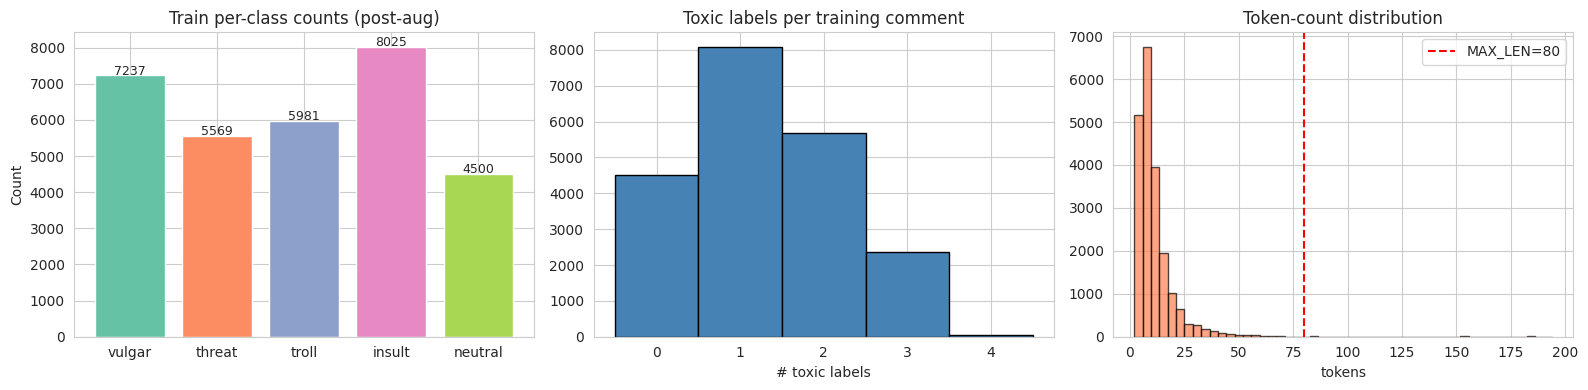

Train tokens: mean=11.1 median=8 max=194
Samples exceeding MAX_LEN: 0.3%


In [6]:
# Section 8: Quick EDA (training split)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
counts = [int(df_train[c].sum()) for c in cfg.LABEL_COLS]
axes[0].bar(cfg.LABEL_COLS, counts, color=sns.color_palette('Set2', len(cfg.LABEL_COLS)))
axes[0].set_title('Train per-class counts (post-aug)'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)
labels_per = df_train[cfg.TOXIC_COLS].sum(axis=1)
axes[1].hist(labels_per, bins=range(0, 6), align='left', color='steelblue', edgecolor='black')
axes[1].set_title('Toxic labels per training comment'); axes[1].set_xlabel('# toxic labels')
wc = df_train['tokens'].apply(len)
axes[2].hist(wc, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[2].axvline(cfg.MAX_LEN, color='red', ls='--', label=f'MAX_LEN={cfg.MAX_LEN}')
axes[2].set_title('Token-count distribution'); axes[2].set_xlabel('tokens'); axes[2].legend()
plt.tight_layout(); plt.show()
print(f'Train tokens: mean={wc.mean():.1f} median={wc.median():.0f} max={wc.max()}')
print(f'Samples exceeding MAX_LEN: {(wc > cfg.MAX_LEN).mean()*100:.1f}%')


In [7]:
# Section 9: Build Word + Character Vocabularies (ORIGINAL train text only)

def build_word_vocab(token_lists, min_freq=2, max_size=40000):
    counter = Counter()
    for toks in token_lists: counter.update(toks)
    words = [w for w, c in counter.most_common() if c >= min_freq][:max_size - 2]
    stoi = {'<PAD>': 0, '<UNK>': 1}
    for i, w in enumerate(words, start=2): stoi[w] = i
    return stoi, {v: k for k, v in stoi.items()}

def build_char_vocab(token_lists, max_size=300):
    counter = Counter()
    for toks in token_lists:
        for t in toks: counter.update(list(t))
    chars = [c for c, _ in counter.most_common(max_size - 2)]
    stoi = {'<PAD>': 0, '<UNK>': 1}
    for i, c in enumerate(chars, start=2): stoi[c] = i
    return stoi

# Vocab from ORIGINAL (non-augmented) train rows so augmentation noise can't inflate it.
vocab_df = df_train[df_train.get('is_aug', pd.Series(0, index=df_train.index)) == 0]
word_stoi, word_itos = build_word_vocab(vocab_df['tokens'].tolist(), cfg.MIN_FREQ, cfg.VOCAB_SIZE)
char_stoi = build_char_vocab(vocab_df['tokens'].tolist(), cfg.CHAR_VOCAB_SIZE)
VOCAB_SIZE = len(word_stoi)
CHAR_VOCAB_SIZE = len(char_stoi)
print(f'(vocab built on {len(vocab_df)} original train rows; full train = {len(df_train)})')

def encode_words(tokens, max_len):
    ids = [word_stoi.get(t, 1) for t in tokens[:max_len]]
    ids += [0] * (max_len - len(ids)); return ids

def encode_chars(tokens, max_len, max_char):
    result = []
    for t in tokens[:max_len]:
        cids = [char_stoi.get(c, 1) for c in t[:max_char]]
        cids += [0] * (max_char - len(cids)); result.append(cids)
    while len(result) < max_len: result.append([0]*max_char)
    return result

val_flat = [t for toks in df_val['tokens'] for t in toks]
oov = sum(1 for t in val_flat if t not in word_stoi) / max(1, len(val_flat)) * 100
print(f'Word vocab: {VOCAB_SIZE:,} | Char vocab: {CHAR_VOCAB_SIZE} | Val OOV: {oov:.2f}%')


(vocab built on 10677 original train rows; full train = 20707)
Word vocab: 8,182 | Char vocab: 78 | Val OOV: 15.48%


In [8]:
# Section 10: FastText Bengali embeddings (cc.bn.300)

FASTTEXT_URL = 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.bn.300.vec.gz'
FASTTEXT_LOCAL = 'cc.bn.300.vec.gz'
candidate_paths = [FASTTEXT_LOCAL, '/kaggle/input/fasttext-bengali/cc.bn.300.vec.gz',
                   os.path.expanduser('~/cc.bn.300.vec.gz')]
ft_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if ft_path is None:
    print('Downloading FastText Bengali vectors...')
    urllib.request.urlretrieve(FASTTEXT_URL, FASTTEXT_LOCAL); ft_path = FASTTEXT_LOCAL
print(f'Loading FastText from: {ft_path}')

pretrained = {}
with gzip.open(ft_path, 'rt', encoding='utf-8') as f:
    f.readline()
    for line in f:
        parts = line.rstrip().split(' ')
        w = parts[0]
        if w in word_stoi:
            vec = np.asarray(parts[1:], dtype=np.float32)
            if len(vec) == cfg.FASTTEXT_DIM: pretrained[w] = vec

embed_matrix = np.zeros((VOCAB_SIZE, cfg.FASTTEXT_DIM), dtype=np.float32)
scale = np.sqrt(3.0 / cfg.FASTTEXT_DIM)
for w, idx in word_stoi.items():
    if w in pretrained: embed_matrix[idx] = pretrained[w]
    elif idx > 1: embed_matrix[idx] = np.random.uniform(-scale, scale, cfg.FASTTEXT_DIM)

coverage = len(pretrained) / (VOCAB_SIZE - 2) * 100
print(f'FastText coverage: {len(pretrained)}/{VOCAB_SIZE-2} ({coverage:.1f}%)')
embed_matrix_tensor = torch.FloatTensor(embed_matrix)
del pretrained, embed_matrix


Loading FastText from: cc.bn.300.vec.gz
FastText coverage: 7851/8180 (96.0%)


In [9]:
# Section 11: Dataset & DataLoaders (model targets = 4 toxic labels)

class BengaliCBDataset(Dataset):
    def __init__(self, df, cfg, is_train=False):
        self.texts = df['tokens'].tolist()
        self.labels = df[cfg.TOXIC_COLS].values.astype(np.float32)
        self.cfg = cfg; self.is_train = is_train
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        tokens = self.texts[idx]
        if self.is_train and self.cfg.WORD_DROPOUT_P > 0:
            tokens = [t if random.random() > self.cfg.WORD_DROPOUT_P else '<UNK>' for t in tokens]
        word_ids = encode_words(tokens, self.cfg.MAX_LEN)
        char_ids = encode_chars(tokens, self.cfg.MAX_LEN, self.cfg.MAX_CHAR_PER_WORD)
        return (torch.LongTensor(word_ids), torch.LongTensor(char_ids),
                torch.FloatTensor(self.labels[idx]))

train_ds = BengaliCBDataset(df_train, cfg, is_train=True)
val_ds   = BengaliCBDataset(df_val, cfg, is_train=False)
test_ds  = BengaliCBDataset(df_test, cfg, is_train=False)
train_loader = DataLoader(train_ds, batch_size=EFFECTIVE_BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=EFFECTIVE_BATCH*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=EFFECTIVE_BATCH*2, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')


Train batches: 161 | Val: 10 | Test: 9


In [10]:
# Section 12: Model (CharCNN + FastText + TextCNN + BiGRU + Attention) -- NO param cap

class SpatialDropout1D(nn.Module):
    def __init__(self, p): super().__init__(); self.p = p
    def forward(self, x):
        if not self.training or self.p == 0: return x
        mask = x.new_ones(x.size(0), 1, x.size(2))
        mask = F.dropout(mask, p=self.p, training=True)
        return x * mask

class CharCNN(nn.Module):
    def __init__(self, cfg, char_vocab_size):
        super().__init__()
        self.char_embed = nn.Embedding(char_vocab_size, cfg.CHAR_EMBED_DIM, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(cfg.CHAR_EMBED_DIM, cfg.CHAR_CNN_FILTERS, k, padding=k//2) for k in cfg.CHAR_KERNELS])
        self.out_dim = cfg.CHAR_CNN_FILTERS * len(cfg.CHAR_KERNELS)
    def forward(self, x):
        B, S, C = x.shape
        x = x.view(B*S, C)
        x = self.char_embed(x).permute(0, 2, 1)
        outs = [F.relu(conv(x)).max(dim=2)[0] for conv in self.convs]
        return torch.cat(outs, dim=1).view(B, S, -1)

class AdditiveAttention(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.W = nn.Linear(hidden, hidden); self.v = nn.Linear(hidden, 1, bias=False)
    def forward(self, h, mask=None):
        energy = torch.tanh(self.W(h))
        scores = self.v(energy).squeeze(-1)
        if mask is not None: scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=1)
        return torch.bmm(attn.unsqueeze(1), h).squeeze(1), attn

class V7Model(nn.Module):
    def __init__(self, cfg, embed_matrix, vocab_size, char_vocab_size):
        super().__init__(); self.cfg = cfg
        self.char_cnn = CharCNN(cfg, char_vocab_size)
        self.word_embed = nn.Embedding(vocab_size, cfg.FASTTEXT_DIM, padding_idx=0)
        if embed_matrix is not None: self.word_embed.weight.data.copy_(embed_matrix)
        if cfg.FREEZE_EMBEDDING: self.word_embed.weight.requires_grad = False
        self.projection = nn.Linear(cfg.FASTTEXT_DIM, cfg.PROJECTION_DIM)
        self.spatial_drop = SpatialDropout1D(cfg.DROPOUT_EMB)
        combined = cfg.PROJECTION_DIM + self.char_cnn.out_dim
        self.text_convs = nn.ModuleList([
            nn.Conv1d(combined, cfg.CNN_FILTERS, k, padding=k//2) for k in cfg.CNN_KERNELS])
        cnn_out = cfg.CNN_FILTERS * len(cfg.CNN_KERNELS)
        self.gru = nn.GRU(cnn_out, cfg.GRU_HIDDEN, num_layers=cfg.GRU_LAYERS,
                          batch_first=True, bidirectional=True,
                          dropout=cfg.DROPOUT if cfg.GRU_LAYERS > 1 else 0)
        gru_out = cfg.GRU_HIDDEN * 2
        self.attention = AdditiveAttention(gru_out)
        self.dropouts = nn.ModuleList([nn.Dropout(cfg.DROPOUT) for _ in range(cfg.NUM_DROPOUT_SAMPLES)])
        self.fc1 = nn.Linear(gru_out * 3, cfg.FC_HIDDEN)
        self.fc2 = nn.Linear(cfg.FC_HIDDEN, cfg.NUM_OUT)
        self._init_weights()
    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'word_embed' in name: continue
            if 'weight' in name and p.dim() >= 2: nn.init.xavier_uniform_(p)
            elif 'bias' in name: nn.init.zeros_(p)
    def forward(self, word_ids, char_ids):
        word_proj = F.relu(self.projection(self.word_embed(word_ids)))
        char_feat = self.char_cnn(char_ids)
        x = torch.cat([word_proj, char_feat], dim=2)
        x = self.spatial_drop(x).permute(0, 2, 1)
        conv_outs = [F.relu(conv(x)).permute(0, 2, 1) for conv in self.text_convs]
        if len({t.size(1) for t in conv_outs}) != 1:
            m = min(t.size(1) for t in conv_outs); conv_outs = [t[:, :m, :] for t in conv_outs]
        x = torch.cat(conv_outs, dim=2)
        gru_out, _ = self.gru(x)
        mask = (word_ids != 0).float()
        attn_ctx, _ = self.attention(gru_out, mask)
        max_pool = gru_out.max(dim=1)[0]
        avg_pool = (gru_out * mask.unsqueeze(2)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)
        feats = torch.cat([attn_ctx, max_pool, avg_pool], dim=1)
        if self.training:
            logits = torch.stack([self.fc2(F.relu(self.fc1(drop(feats)))) for drop in self.dropouts], 0).mean(0)
        else:
            logits = self.fc2(F.relu(self.fc1(feats)))
        return logits

set_seed(SEED)
model = V7Model(cfg, embed_matrix_tensor, VOCAB_SIZE, CHAR_VOCAB_SIZE)
total_params = sum(p.numel() for p in model.parameters())
trainable_frozen = sum(p.numel() for p in model.parameters() if p.requires_grad)
embed_params = cfg.FASTTEXT_DIM * VOCAB_SIZE
print('=' * 60)
print('              PARAMETER COUNT (no cap)')
print('=' * 60)
print(f'  Word embedding (FastText): {embed_params:>12,}')
print(f'  Rest of the network:       {total_params-embed_params:>12,}')
print(f'  TOTAL parameters:          {total_params:>12,} ({total_params/1e6:.2f}M)')
print(f'  Trainable while emb frozen:{trainable_frozen:>12,} ({trainable_frozen/1e6:.2f}M)')
print(f'  Trainable after unfreeze:  {total_params:>12,} ({total_params/1e6:.2f}M)')
print('=' * 60)

if NUM_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'Wrapped with nn.DataParallel across {NUM_GPUS} GPUs (T4 x2).')
model = model.to(device)


              PARAMETER COUNT (no cap)
  Word embedding (FastText):    2,454,600
  Rest of the network:         12,780,416
  TOTAL parameters:            15,235,016 (15.24M)
  Trainable while emb frozen:  12,780,416 (12.78M)
  Trainable after unfreeze:    15,235,016 (15.24M)
Wrapped with nn.DataParallel across 2 GPUs (T4 x2).


In [11]:
# Section 13: Focal Loss (no pos_weight) + optimizer + scheduler

class FocalBCELoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None, smoothing=0.0):
        super().__init__()
        self.gamma = gamma; self.pos_weight = pos_weight; self.smoothing = smoothing
    def forward(self, logits, targets):
        if self.smoothing > 0:
            targets = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none', pos_weight=self.pos_weight)
        probs = torch.sigmoid(logits)
        p_t = targets * probs + (1 - targets) * (1 - probs)
        return ((1 - p_t) ** self.gamma * bce).mean()

pos_weight = None
if cfg.USE_POS_WEIGHT:
    tl = df_train[cfg.TOXIC_COLS].values
    pos = tl.sum(0); neg = len(tl) - pos
    pos_weight = torch.FloatTensor(np.sqrt(neg / np.clip(pos, 1, None))).to(device)
else:
    print('pos_weight: DISABLED (balance handled by all-class augmentation + threshold tuning)')

criterion = FocalBCELoss(cfg.FOCAL_GAMMA, pos_weight, cfg.LABEL_SMOOTHING) if cfg.USE_FOCAL_LOSS else nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f'Loss: {"Focal" if cfg.USE_FOCAL_LOSS else "BCE"} (gamma={cfg.FOCAL_GAMMA}, smoothing={cfg.LABEL_SMOOTHING})')

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
total_steps = cfg.EPOCHS * len(train_loader)
warmup_steps = int(total_steps * cfg.WARMUP_RATIO)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))

scheduler = LambdaLR(optimizer, lr_lambda)
print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')


pos_weight: DISABLED (balance handled by all-class augmentation + threshold tuning)
Loss: Focal (gamma=2.0, smoothing=0.05)
Total steps: 5635 | Warmup: 563


In [12]:
# Section 14: Training Loop (two-phase; fixed unfreeze LR; no mixup/SWA; honest metrics)

def neutral_from_toxic(binary_toxic):
    neu = (binary_toxic.sum(axis=1) == 0).astype(int).reshape(-1, 1)
    return np.concatenate([binary_toxic, neu], axis=1)

def train_one_epoch(model, loader, criterion, optimizer, scheduler, global_step):
    model.train(); total_loss = 0.0; preds_all, labels_all = [], []
    for word_ids, char_ids, labels in loader:
        word_ids = word_ids.to(device); char_ids = char_ids.to(device); labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(word_ids, char_ids)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), cfg.GRAD_CLIP)
        optimizer.step(); scheduler.step(); global_step += 1
        total_loss += loss.item()
        preds_all.append(torch.sigmoid(logits).detach().cpu().numpy())
        labels_all.append(labels.detach().cpu().numpy())
    preds_all = np.vstack(preds_all); labels_all = np.vstack(labels_all)
    f1 = f1_score((labels_all > 0.5).astype(int), (preds_all > 0.5).astype(int), average='macro', zero_division=0)
    return total_loss / len(loader), f1, global_step

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); total_loss = 0.0; preds_all, labels_all = [], []
    for word_ids, char_ids, labels in loader:
        word_ids = word_ids.to(device); char_ids = char_ids.to(device); labels = labels.to(device)
        logits = model(word_ids, char_ids)
        total_loss += criterion(logits, labels).item()
        preds_all.append(torch.sigmoid(logits).cpu().numpy())
        labels_all.append(labels.cpu().numpy())
    preds_all = np.vstack(preds_all); labels_all = np.vstack(labels_all)
    bin_pred5 = neutral_from_toxic((preds_all > 0.5).astype(int))
    bin_true5 = neutral_from_toxic((labels_all > 0.5).astype(int))
    macro_f1 = f1_score(bin_true5, bin_pred5, average='macro', zero_division=0)
    per_class = f1_score(bin_true5, bin_pred5, average=None, zero_division=0)
    return total_loss / len(loader), macro_f1, per_class, preds_all, labels_all

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [],
           'val_per_class_f1': [], 'lr': [], 'phase': []}
best_val_f1, best_epoch, patience_counter, global_step, best_state = 0.0, 0, 0, 0, None

print(f'Training {cfg.EPOCHS} epochs | Phase1 frozen 1-{cfg.UNFREEZE_AT_EPOCH-1}, Phase2 unfrozen {cfg.UNFREEZE_AT_EPOCH}-{cfg.EPOCHS}')
print('=' * 95)
for epoch in range(1, cfg.EPOCHS + 1):
    t0 = time.time()
    if epoch == cfg.UNFREEZE_AT_EPOCH:
        # FIX: keep body at full LR on a fresh cosine over remaining steps; embeddings at 0.1x.
        base = model.module if hasattr(model, 'module') else model
        base.word_embed.weight.requires_grad = True
        embed_p = [base.word_embed.weight]
        other_p = [p for n, p in base.named_parameters() if 'word_embed' not in n and p.requires_grad]
        optimizer = AdamW([
            {'params': embed_p, 'lr': cfg.LR * cfg.UNFREEZE_LR_FACTOR},
            {'params': other_p, 'lr': cfg.LR}], weight_decay=cfg.WEIGHT_DECAY)
        remaining = (cfg.EPOCHS - epoch + 1) * len(train_loader)
        scheduler = LambdaLR(optimizer, lambda s: 0.5 * (1.0 + math.cos(math.pi * min(1.0, s / remaining))))
        print(f'  >> Unfroze embeddings at epoch {epoch} (body LR kept at {cfg.LR:.1e}, embed LR {cfg.LR*cfg.UNFREEZE_LR_FACTOR:.1e})')
    phase = 'Frozen' if epoch < cfg.UNFREEZE_AT_EPOCH else 'Unfrozen'

    train_loss, train_f1, global_step = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, global_step)
    val_loss, val_f1, val_pc, _, _ = evaluate(model, val_loader, criterion)
    lr_now = optimizer.param_groups[-1]['lr']

    for k, v in [('train_loss', train_loss), ('val_loss', val_loss), ('train_f1', train_f1),
                 ('val_f1', val_f1), ('val_per_class_f1', val_pc.tolist()), ('lr', lr_now), ('phase', phase)]:
        history[k].append(v)

    if val_f1 > best_val_f1:
        best_val_f1, best_epoch = val_f1, epoch
        best_state = copy.deepcopy((model.module if hasattr(model, 'module') else model).state_dict())
        patience_counter = 0; marker = ' *BEST*'
    else:
        patience_counter += 1; marker = ''
    print(f'Epoch {epoch:02d}/{cfg.EPOCHS} [{phase:>8s}] TrLoss {train_loss:.4f} VaLoss {val_loss:.4f} '
          f'TrF1 {train_f1:.4f} VaF1 {val_f1:.4f} Gap {train_f1-val_f1:+.4f} LR {lr_now:.2e} {time.time()-t0:.0f}s{marker}')
    if patience_counter >= cfg.PATIENCE:
        print(f'Early stopping at epoch {epoch} (patience={cfg.PATIENCE}).'); break

print('=' * 95)
print(f'Best epoch {best_epoch} | Best Val Macro-F1 (5-class) {best_val_f1:.4f}')
base = model.module if hasattr(model, 'module') else model
base.load_state_dict(best_state)
print('Restored best model weights.')


Training 35 epochs | Phase1 frozen 1-5, Phase2 unfrozen 6-35
Epoch 01/35 [  Frozen] TrLoss 0.1549 VaLoss 0.1215 TrF1 0.1815 VaF1 0.4596 Gap -0.2781 LR 2.29e-04 32s *BEST*
Epoch 02/35 [  Frozen] TrLoss 0.1298 VaLoss 0.1083 TrF1 0.4943 VaF1 0.5892 Gap -0.0949 LR 4.58e-04 30s *BEST*
Epoch 03/35 [  Frozen] TrLoss 0.1185 VaLoss 0.0996 TrF1 0.5857 VaF1 0.6535 Gap -0.0678 LR 6.86e-04 32s *BEST*
Epoch 04/35 [  Frozen] TrLoss 0.1104 VaLoss 0.0939 TrF1 0.6372 VaF1 0.6835 Gap -0.0463 LR 7.99e-04 34s *BEST*
Epoch 05/35 [  Frozen] TrLoss 0.1037 VaLoss 0.0871 TrF1 0.6784 VaF1 0.6858 Gap -0.0074 LR 7.96e-04 34s *BEST*
  >> Unfroze embeddings at epoch 6 (body LR kept at 8.0e-04, embed LR 8.0e-05)
Epoch 06/35 [Unfrozen] TrLoss 0.0996 VaLoss 0.0891 TrF1 0.6947 VaF1 0.6607 Gap +0.0340 LR 7.98e-04 34s
Epoch 07/35 [Unfrozen] TrLoss 0.0914 VaLoss 0.0868 TrF1 0.7378 VaF1 0.6916 Gap +0.0462 LR 7.91e-04 34s *BEST*
Epoch 08/35 [Unfrozen] TrLoss 0.0851 VaLoss 0.0847 TrF1 0.7609 VaF1 0.7117 Gap +0.0492 LR 7.80e-0

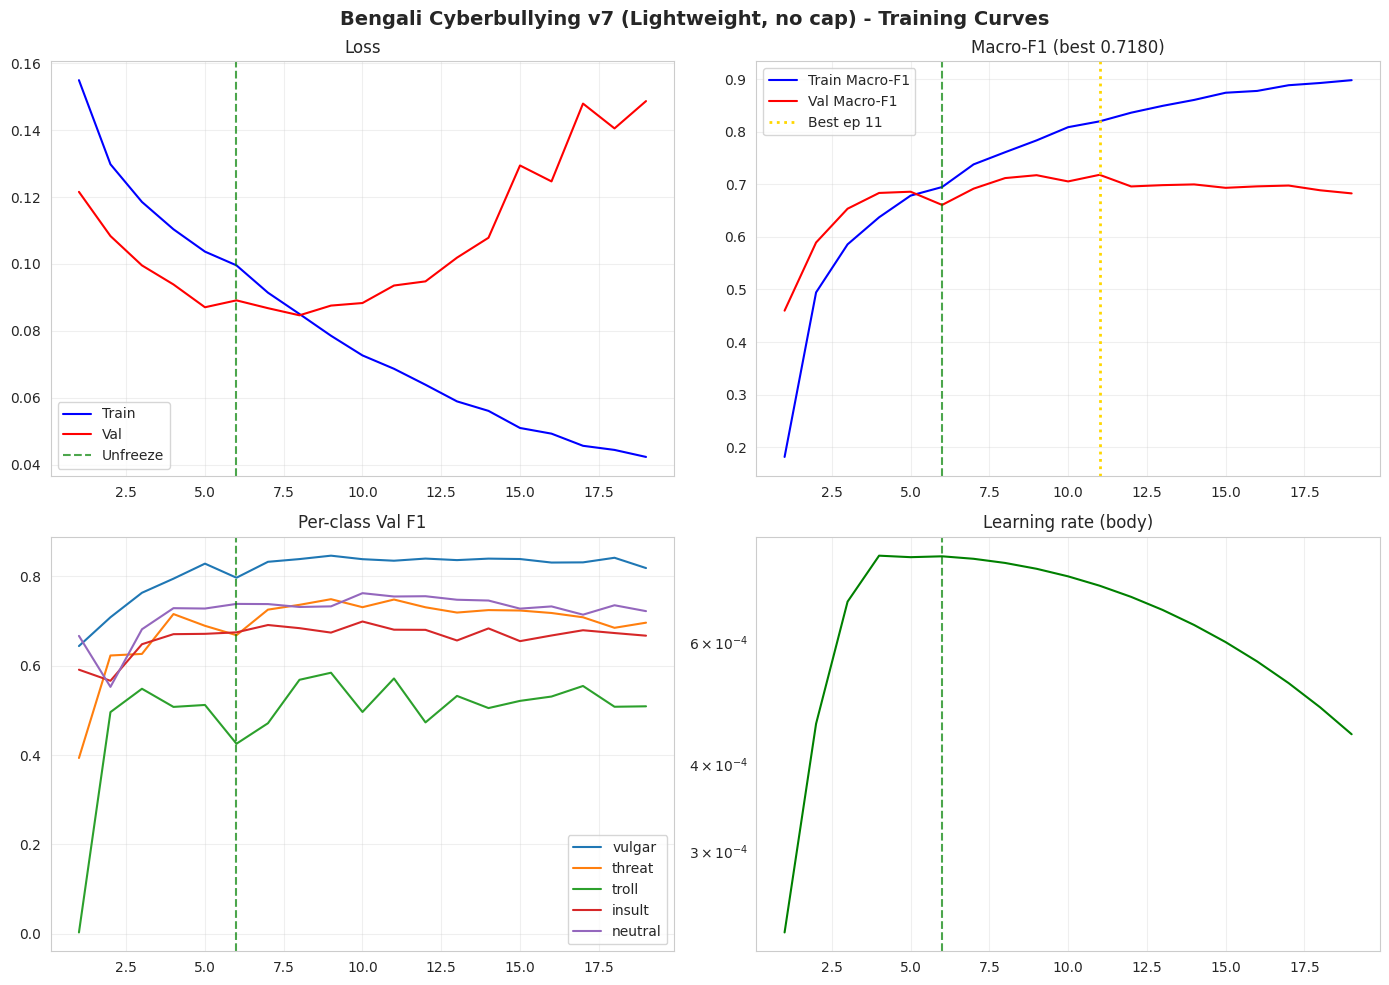

Best-epoch train-val F1 gap: 0.1016 (Moderate overfitting)


In [13]:
# Section 15: Training curves

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, len(history['train_loss']) + 1)
uf = cfg.UNFREEZE_AT_EPOCH
axes[0,0].plot(ep, history['train_loss'], 'b-', label='Train'); axes[0,0].plot(ep, history['val_loss'], 'r-', label='Val')
if uf <= len(ep): axes[0,0].axvline(uf, color='green', ls='--', alpha=0.7, label='Unfreeze')
axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,1].plot(ep, history['train_f1'], 'b-', label='Train Macro-F1'); axes[0,1].plot(ep, history['val_f1'], 'r-', label='Val Macro-F1')
axes[0,1].axvline(best_epoch, color='gold', ls=':', lw=2, label=f'Best ep {best_epoch}')
if uf <= len(ep): axes[0,1].axvline(uf, color='green', ls='--', alpha=0.7)
axes[0,1].set_title(f'Macro-F1 (best {best_val_f1:.4f})'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
pc = np.array(history['val_per_class_f1'])
for i, c in enumerate(cfg.LABEL_COLS):
    axes[1,0].plot(ep, pc[:, i], '-', label=c, lw=1.5)
if uf <= len(ep): axes[1,0].axvline(uf, color='green', ls='--', alpha=0.7)
axes[1,0].set_title('Per-class Val F1'); axes[1,0].legend(loc='lower right'); axes[1,0].grid(alpha=0.3)
axes[1,1].plot(ep, history['lr'], 'g-'); axes[1,1].set_yscale('log')
if uf <= len(ep): axes[1,1].axvline(uf, color='green', ls='--', alpha=0.7)
axes[1,1].set_title('Learning rate (body)'); axes[1,1].grid(alpha=0.3)
plt.suptitle('Bengali Cyberbullying v7 (Lightweight, no cap) - Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('v7_training_curves.png', dpi=150, bbox_inches='tight'); plt.show()
best_gap = history['train_f1'][best_epoch-1] - history['val_f1'][best_epoch-1]
print(f'Best-epoch train-val F1 gap: {best_gap:.4f} '
      f'({"Good" if best_gap < 0.08 else "Moderate" if best_gap < 0.12 else "High"} overfitting)')


In [14]:
# Section 16: Per-class threshold tuning on the (clean) validation set

_, _, _, val_preds, val_labels = evaluate(model, val_loader, criterion)

def tune_thresholds(preds, labels, cfg):
    grid = np.arange(cfg.THRESH_MIN, cfg.THRESH_MAX + 1e-9, cfg.THRESH_STEP)
    best = np.full(preds.shape[1], 0.5)
    for c in range(preds.shape[1]):
        bf = -1.0
        for t in grid:
            f1 = f1_score(labels[:, c], (preds[:, c] > t).astype(int), zero_division=0)
            if f1 > bf: bf, best[c] = f1, t
    return best

tuned = tune_thresholds(val_preds, val_labels, cfg)
print('Tuned thresholds (toxic classes):')
for c, t in zip(cfg.TOXIC_COLS, tuned): print(f'  {c:>8s}: {t:.2f}')

def apply_thresholds(preds, thresholds):
    out = np.zeros_like(preds)
    for c in range(preds.shape[1]): out[:, c] = (preds[:, c] > thresholds[c]).astype(int)
    return out

def to5(binary_toxic):
    neu = (binary_toxic.sum(axis=1) == 0).astype(int).reshape(-1, 1)
    return np.concatenate([binary_toxic, neu], axis=1)

default_f1 = f1_score(to5((val_preds > 0.5).astype(int)), to5((val_labels > 0.5).astype(int)), average='macro', zero_division=0)
tuned_f1 = f1_score(to5(apply_thresholds(val_preds, tuned)), to5((val_labels > 0.5).astype(int)), average='macro', zero_division=0)
print(f'\nVal Macro-F1 (0.5): {default_f1:.4f} | (tuned): {tuned_f1:.4f} | gain +{(tuned_f1-default_f1)*100:.2f}%')


Tuned thresholds (toxic classes):
    vulgar: 0.56
    threat: 0.50
     troll: 0.44
    insult: 0.46

Val Macro-F1 (0.5): 0.7180 | (tuned): 0.7237 | gain +0.57%


In [15]:
# Section 17: Final test evaluation (derive neutral, report all 5 classes)

@torch.no_grad()
def predict_probs(model, loader):
    model.eval(); probs, labels = [], []
    for word_ids, char_ids, y in loader:
        logits = model(word_ids.to(device), char_ids.to(device))
        probs.append(torch.sigmoid(logits).cpu().numpy()); labels.append(y.numpy())
    return np.vstack(probs), np.vstack(labels)

test_probs, test_toxic_labels = predict_probs(model, test_loader)
test_pred_toxic = apply_thresholds(test_probs, tuned)
test_pred5 = to5(test_pred_toxic)
test_true5 = to5((test_toxic_labels > 0.5).astype(int))
neutral_prob = (1.0 - test_probs.max(axis=1, keepdims=True))
test_probs5 = np.concatenate([test_probs, neutral_prob], axis=1)

macro_f1 = f1_score(test_true5, test_pred5, average='macro', zero_division=0)
micro_f1 = f1_score(test_true5, test_pred5, average='micro', zero_division=0)
weighted_f1 = f1_score(test_true5, test_pred5, average='weighted', zero_division=0)
samples_f1 = f1_score(test_true5, test_pred5, average='samples', zero_division=0)
h_loss = hamming_loss(test_true5, test_pred5)
try: roc_auc = roc_auc_score(test_true5, test_probs5, average='macro')
except ValueError: roc_auc = float('nan')
try: pr_auc = average_precision_score(test_true5, test_probs5, average='macro')
except ValueError: pr_auc = float('nan')

print('=' * 64)
print('         FINAL TEST EVALUATION (v7 lightweight, neutral derived)')
print('=' * 64)
print(f'  Macro-F1:     {macro_f1:.4f}')
print(f'  Micro-F1:     {micro_f1:.4f}')
print(f'  Weighted-F1:  {weighted_f1:.4f}')
print(f'  Samples-F1:   {samples_f1:.4f}')
print(f'  Hamming Loss: {h_loss:.4f}')
print(f'  ROC-AUC:      {roc_auc:.4f}')
print(f'  PR-AUC:       {pr_auc:.4f}')
print(f'  Total params: {total_params:,} ({total_params/1e6:.2f}M)')
print('=' * 64)
print('\nPer-class report (precision/recall/F1):')
print(classification_report(test_true5, test_pred5, target_names=cfg.LABEL_COLS, digits=4, zero_division=0))


         FINAL TEST EVALUATION (v7 lightweight, neutral derived)
  Macro-F1:     0.7130
  Micro-F1:     0.7051
  Weighted-F1:  0.7094
  Samples-F1:   0.6815
  Hamming Loss: 0.1575
  ROC-AUC:      0.8891
  PR-AUC:       0.7772
  Total params: 15,235,016 (15.24M)

Per-class report (precision/recall/F1):
              precision    recall  f1-score   support

      vulgar     0.8920    0.8404    0.8654       570
      threat     0.6976    0.7259    0.7115       321
       troll     0.5232    0.6406    0.5760       651
      insult     0.6607    0.7282    0.6928       655
     neutral     0.7765    0.6703    0.7195       819

   micro avg     0.6958    0.7145    0.7051      3016
   macro avg     0.7100    0.7211    0.7130      3016
weighted avg     0.7101    0.7145    0.7094      3016
 samples avg     0.6883    0.7047    0.6815      3016



## Section 18: Multi-seed ensemble (optional, recommended for best output)

Average the toxic probabilities of several seeds, derive neutral, apply tuned thresholds. This is
the most reliable way to squeeze the last ~0.5-1.5% from the from-scratch model.


In [16]:
# Section 19: Ensemble implementation (consistent with this pipeline)

def train_with_seed(seed, verbose=False):
    set_seed(seed)
    m = V7Model(cfg, embed_matrix_tensor, VOCAB_SIZE, CHAR_VOCAB_SIZE)
    if NUM_GPUS > 1: m = nn.DataParallel(m)
    m = m.to(device)
    opt = AdamW(filter(lambda p: p.requires_grad, m.parameters()), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    sch = LambdaLR(opt, lr_lambda)
    gstep, best_f1, best_sd = 0, 0.0, None
    for epoch in range(1, cfg.EPOCHS + 1):
        if epoch == cfg.UNFREEZE_AT_EPOCH:
            base = m.module if hasattr(m, 'module') else m
            base.word_embed.weight.requires_grad = True
            ep_ = [base.word_embed.weight]
            op_ = [p for n, p in base.named_parameters() if 'word_embed' not in n and p.requires_grad]
            opt = AdamW([{'params': ep_, 'lr': cfg.LR*cfg.UNFREEZE_LR_FACTOR},
                         {'params': op_, 'lr': cfg.LR}], weight_decay=cfg.WEIGHT_DECAY)
            rem = (cfg.EPOCHS - epoch + 1) * len(train_loader)
            sch = LambdaLR(opt, lambda s: 0.5 * (1.0 + math.cos(math.pi * min(1.0, s/rem))))
        _, _, gstep = train_one_epoch(m, train_loader, criterion, opt, sch, gstep)
        _, vf1, _, _, _ = evaluate(m, val_loader, criterion)
        if vf1 > best_f1:
            best_f1 = vf1
            best_sd = copy.deepcopy((m.module if hasattr(m, 'module') else m).state_dict())
        if verbose: print(f'  seed {seed} ep {epoch}/{cfg.EPOCHS} ValF1 {vf1:.4f}')
    (m.module if hasattr(m, 'module') else m).load_state_dict(best_sd)
    probs, _ = predict_probs(m, test_loader)
    print(f'Seed {seed}: best Val Macro-F1 {best_f1:.4f}')
    return probs

def ensemble(prob_list, thresholds):
    avg = np.mean(prob_list, axis=0)
    return avg, to5(apply_thresholds(avg, thresholds))

print('Single-seed (42) test Macro-F1:', f'{macro_f1:.4f}')
print('Run full ensemble with:')
print('  all_probs = [train_with_seed(s) for s in cfg.ENSEMBLE_SEEDS]')
print('  avg, ens_pred5 = ensemble(all_probs, tuned)')
print('  print(f1_score(test_true5, ens_pred5, average="macro"))')


Single-seed (42) test Macro-F1: 0.7130
Run full ensemble with:
  all_probs = [train_with_seed(s) for s in cfg.ENSEMBLE_SEEDS]
  avg, ens_pred5 = ensemble(all_probs, tuned)
  print(f1_score(test_true5, ens_pred5, average="macro"))


In [17]:
# Section 20: Save checkpoint + summary

base_model = model.module if hasattr(model, 'module') else model
checkpoint = {
    'model_state_dict': base_model.state_dict(),
    'config': {k: v for k, v in vars(cfg).items() if not k.startswith('_')},
    'thresholds': tuned.tolist(), 'toxic_cols': cfg.TOXIC_COLS,
    'history': history, 'word_stoi': word_stoi, 'char_stoi': char_stoi,
    'best_epoch': best_epoch, 'best_val_f1': best_val_f1,
    'test_macro_f1': macro_f1, 'total_params': total_params,
}
torch.save(checkpoint, 'bengali_cyberbullying_v7_lightweight.pt')
print(f'Saved checkpoint ({os.path.getsize("bengali_cyberbullying_v7_lightweight.pt")/1e6:.1f} MB)')

summary = {
    'version': 'v7-lightweight-nocap',
    'model': 'CharCNN + FastText + TextCNN + BiGRU + Attention',
    'total_params': int(total_params),
    'total_params_millions': round(total_params/1e6, 3),
    'predicts': cfg.TOXIC_COLS, 'neutral': 'derived as NOT(any toxic)',
    'hardware': f'{NUM_GPUS}x GPU (DataParallel)',
    'train_size': len(df_train), 'val_size': len(df_val), 'test_size': len(df_test),
    'best_epoch': best_epoch, 'best_val_macro_f1': round(best_val_f1, 4),
    'test_macro_f1': round(macro_f1, 4), 'test_micro_f1': round(micro_f1, 4),
    'test_weighted_f1': round(weighted_f1, 4), 'test_hamming_loss': round(h_loss, 4),
    'tuned_thresholds': dict(zip(cfg.TOXIC_COLS, [round(float(t),2) for t in tuned])),
    'changes': ['removed 10M param cap', 'scaled up architecture', 'fixed unfreeze LR collapse',
                'stronger regularization', 'all-class train-only augmentation'],
}
with open('v7_summary.json', 'w') as f: json.dump(summary, f, indent=2, ensure_ascii=False)
print('Saved v7_summary.json')
print('\nFINAL: Test Macro-F1 = %.4f | Params utilized = %d (%.2fM)' % (macro_f1, total_params, total_params/1e6))


Saved checkpoint (61.2 MB)
Saved v7_summary.json

FINAL: Test Macro-F1 = 0.7130 | Params utilized = 15235016 (15.24M)


## Section 21: Notes

- The exact parameter count utilized is printed in Section 12 and again in the final summary.
- This from-scratch model is data/label-limited (subjective, overlapping `troll`/`insult`), so
  removing the cap mainly raises the parameter number, not the score. For a genuine accuracy gain
  use the transformer notebook (`bengali-cyberbullying-transformer.ipynb`).
- For the best lightweight number, run the multi-seed ensemble in Section 19.
